In [3]:
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

In [4]:
with open("./dataset/training_data.json") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

display(df.head())

,src_port,dst_port,packet_size,duration_ms,protocol
0,22,51444,1407,240,TCP
1,22,60588,1435,465,UDP
2,80,17494,187,111,TCP
3,443,12685,830,383,TCP
4,80,59175,1209,122,TCP


In [5]:
df_encoded = pd.get_dummies(df, columns=["protocol"], drop_first=True)

X = df_encoded[
    [
        "src_port",
        "dst_port",
        "packet_size",
        "duration_ms",
        "protocol_UDP"
    ]
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1000, 5)


In [6]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=(3,),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

autoencoder.fit(X_scaled, X_scaled)

print("Autoencoder trained successfully.")

Autoencoder trained successfully.


/home/pari/jupyter-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [7]:
reconstructed = autoencoder.predict(X_scaled)

reconstruction_error = np.mean(
    (X_scaled - reconstructed) ** 2,
    axis=1
)

threshold = np.percentile(reconstruction_error,95)

print("Threshold:", threshold)

Threshold: 1.2856745740654947


In [8]:
predictions = np.where(
    reconstruction_error > threshold,
    -1,
    1
)

print("Normal:", np.sum(predictions == 1))
print("Anomaly:", np.sum(predictions == -1))

Normal: 950
Anomaly: 50


In [9]:
joblib.dump(autoencoder, "autoencoder_model.joblib")
joblib.dump(scaler, "autoencoder_scaler.joblib")

print("Autoencoder model saved.")

Autoencoder model saved.


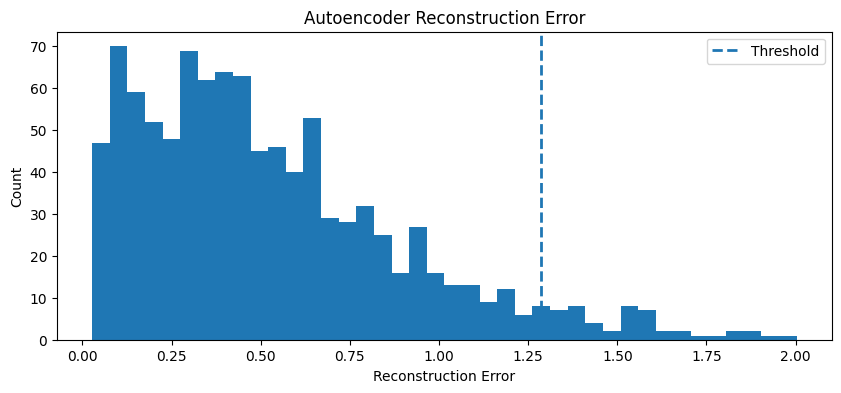

In [10]:
plt.figure(figsize=(10,4))

plt.hist(reconstruction_error, bins=40)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="Threshold"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error")

plt.legend()
plt.show()

In [11]:
test_samples = df.sample(10, random_state=42)

test_encoded = pd.get_dummies(
    test_samples,
    columns=["protocol"],
    drop_first=True
)

test_encoded = test_encoded.reindex(
    columns=df_encoded.columns,
    fill_value=0
)

test_scaled = scaler.transform(test_encoded)

reconstructed = autoencoder.predict(test_scaled)

error = np.mean(
    (test_scaled - reconstructed)**2,
    axis=1
)

prediction = np.where(error > threshold, -1, 1)

result = test_samples.copy()
result["Reconstruction Error"] = error
result["Prediction"] = np.where(
    prediction == 1,
    "Normal",
    "Anomaly"
)
display(result)

,src_port,dst_port,packet_size,duration_ms,protocol,Reconstruction Error,Prediction
521,443,20284,871,186,UDP,0.038860,Normal
737,80,3056,1021,325,TCP,0.237490,Normal
740,80,62262,570,368,TCP,0.387629,Normal
660,22,9659,101,168,TCP,0.421941,Normal
411,8080,11214,1212,227,UDP,0.568617,Normal
678,80,48100,737,218,UDP,0.135610,Normal
626,80,58836,334,211,TCP,0.647660,Normal
513,443,59730,679,190,TCP,0.452893,Normal
859,8080,20977,289,333,UDP,1.572924,Anomaly
136,8080,62604,1336,450,UDP,1.364524,Anomaly
